# Canibalização, correlação e clusters de produtos/marcas — Liah

**Pergunta de negócio:** quando um produto vende mais (ex.: um whey concentrado em promoção), as vendas são **novas**
ou foram **tiradas de outro produto do mesmo grupo/subgrupo**?

Quatro olhares complementares (cada um tem um ponto cego, por isso o cruzamento):
1. **Participação no subgrupo** — quem ganha e quem perde espaço ao longo do tempo.
2. **Episódios de pico** — nas semanas em que um produto disparou, o resto do subgrupo caiu? Quanto? (*taxa de canibalização*)
3. **Correlação** das variações semanais, descontando o movimento geral da loja (negativa = um sobe quando o outro desce).
4. **Cesta** — os dois saem juntos no mesmo pedido? (*lift* alto = complementares; baixo = substitutos)

E dois agrupamentos por **comportamento de compra** (não pelo cadastro):
- **KNN** (vizinhos mais próximos): para cada produto, os produtos mais parecidos em preço, desconto, canal e padrão de vendas
  → candidatos a substitutos. O KNN também testa se o cadastro (subgrupo) reflete o comportamento real.
- **K-means** (BigQuery ML via `bigframes`) para agrupar produtos e marcas em perfis.

Saída: tabela de pares com a classificação **"concorrem entre si" / "complementares" / "sem relação clara"**, pronta para o Metabase,
e a recomendação de **em que nível prever** (ver notebook de previsão: top-down por participação).

**Organização da pasta:** na raiz ficam só os notebooks. `modulos/` (liah_dados.py, previsao_modelos.py), `dados/` (histórico e cache das consultas), `saida/` (resultados), `dashboard/` (painel), `docs/` (guia e SQL), `teste/` (dados fictícios).

> Análise interna, sujeita a validação pela área responsável. Correlação não prova causa: confirme os pares com o time comercial
> (promoções, rupturas de estoque, lançamentos).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instala SÓ o que estiver faltando. Não atualiza bibliotecas que o Colab já traz (numpy, pandas, pyarrow, scikit-learn...):
# atualizar biblioteca já carregada pode derrubar o kernel ("kernel restarted") sem mensagem de erro.
import importlib.util, subprocess, sys
faltam = [p for m, p in {'bigframes': 'bigframes', 'sklearn': 'scikit-learn', 'holidays': 'holidays'}.items() if importlib.util.find_spec(m) is None]
if faltam:
    print('Instalando:', faltam)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *faltam], check=True)
else:
    print('Todas as bibliotecas já estão instaladas.')

Todas as bibliotecas já estão instaladas.


In [3]:
import os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

MODO = os.environ.get('LIAH_MODO', 'bigquery')
PROJETO_EXECUCAO = 'prj-sbx-data-liah-4956'    # projeto que executa e é FATURADO pelas consultas (sandbox Liah)
LOCAL_BQ = None
PASTA_DRIVE = '/content/drive/MyDrive/previsao_vendas'   # pasta no Drive com os .py (None = enviar arquivos a cada sessão)
PASTA_CACHE = 'dados/cache_dados'   # cópia local de cada consulta (permite reprocessar offline)
REUSAR_CACHE_HORAS = 12         # reaproveita consultas idênticas feitas há menos de 12 h (0 = sempre consultar o BigQuery)
COLUNAS_MANUAIS = {}
DEDUP_ITENS = False

INICIO_ANALISE = '2025-01-01'
NIVEL_COMPARACAO = 'subgrupo'   # canibalização é medida dentro deste nível ('subgrupo' ou 'grupo')
METRICA = 'unidades'            # demanda física; 'faturamento' também funciona
MIN_SEMANAS_COM_VENDA = 20      # produtos com menos semanas vendendo ficam fora (ruído)
SEMANAS_BASE = 8                # linha de base = mediana das 8 semanas anteriores
LIMIAR_PICO = 1.5               # pico = semana com vendas >= 1,5 × linha de base
MIN_DELTA_PICO = 5              # ...e pelo menos 5 unidades acima da base
MIN_EPISODIOS = 3               # mínimo de picos para confiar na taxa
K_VIZINHOS = 5
MAX_PARES_POR_GRUPO = 40       # pares produto×produto só entre os 40 maiores de cada subgrupo (evita milhões de pares)
N_CLUSTERS = None               # None = escolhe pelo silhouette entre 3 e 8
DIAS_CESTA, TOP_PRODUTOS_CESTA = 365, 150
SEED = 42
DATASET_SAIDA = None            # ex.: 'prj-sbx-data-liah-4956.previsao_vendas'; NUNCA gold_core/silver

## 1. Conexão e colunas

In [4]:
import os, sys, importlib
if PASTA_DRIVE:
    if not os.path.isdir('/content/drive/MyDrive'):   # monta só se ainda não estiver montado (ex.: pelo ícone do Drive na barra lateral)
        from google.colab import drive
        try:
            drive.mount('/content/drive')
        except ValueError:
            drive.mount('/content/drive', force_remount=True)   # 2ª tentativa limpa uma montagem anterior travada
    os.makedirs(PASTA_DRIVE, exist_ok=True); os.chdir(PASTA_DRIVE)
    print('Usando a pasta', PASTA_DRIVE)

# Organização da pasta: só os notebooks na raiz; módulos em modulos/, histórico e cache em dados/,
# resultados em saida/, painel em dashboard/, documentação em docs/.
PASTA_MODULOS = 'modulos'
sys.dont_write_bytecode = True     # não cria a pasta __pycache__ no Drive
os.makedirs(PASTA_MODULOS, exist_ok=True)
for a in ('liah_dados.py', 'previsao_modelos.py'):   # compatibilidade: módulo esquecido na raiz vai para modulos/
    if os.path.exists(a) and not os.path.exists(os.path.join(PASTA_MODULOS, a)):
        os.replace(a, os.path.join(PASTA_MODULOS, a))
faltando = [a for a in ('liah_dados.py', 'previsao_modelos.py') if not os.path.exists(os.path.join(PASTA_MODULOS, a))]
if faltando:
    from google.colab import files
    print(f'Envie os módulos (vão para {PASTA_MODULOS}/):', faltando)
    for nome, conteudo in files.upload().items():
        with open(os.path.join(PASTA_MODULOS, nome), 'wb') as f:
            f.write(conteudo)
sys.path.insert(0, os.path.abspath(PASTA_MODULOS))
import liah_dados as ld, previsao_modelos as pm
importlib.reload(ld); importlib.reload(pm)

if MODO == 'bigquery':
    try:
        from google.colab import auth
        auth.authenticate_user()     # login Google com acesso ao projeto
    except ImportError:
        pass                         # fora do Colab: usa as credenciais padrão (gcloud auth application-default login)

fonte = ld.Fonte(MODO, PASTA_CACHE, PROJETO_EXECUCAO, LOCAL_BQ, reusar_cache_horas=REUSAR_CACHE_HORAS)
cols = ld.detectar_colunas(fonte, COLUNAS_MANUAIS)
print(f'Modo: {MODO} | consultas executadas e faturadas em: {PROJETO_EXECUCAO} | tabelas lidas de: {ld.PROJETO}')
print('Colunas detectadas nas tabelas:')
display(cols.resumo())

Usando a pasta /content/drive/MyDrive/previsao_vendas
Modo: bigquery | consultas executadas e faturadas em: prj-sbx-data-liah-4956 | tabelas lidas de: prj-data-lakehouse-prd-9459
Colunas detectadas nas tabelas:


,campo,coluna encontrada,tabela
0,produto_id,id,dim_liah_produtos
1,produto_nome,nome,dim_liah_produtos
2,marca,marca,dim_liah_produtos
3,grupo,— não encontrada —,
4,subgrupo,— não encontrada —,
5,produto_atualizacao,data_atualizacao,dim_liah_produtos
6,uf,estado,pedidos


## 2. Dados: produto × semana (sem pedidos extremos)
A agregação pesada roda **no BigQuery**: vem para o notebook só o cubo produto × semana × canal, já somado.

In [5]:
diaria = fonte.df(ld.sql_diaria(cols, DEDUP_ITENS), 'diaria').set_index('ds')
ultima_sem = ld.ultima_semana_completa(diaria.index.max())
# Só o cubo de PRODUTO (semana × produto × canal): é o que a canibalização usa; baixado uma vez.
cubos = ld.Cubos(fonte, cols, DEDUP_ITENS, geo=False)

chave = ['id_produto', 'produto_nome', 'marca', 'grupo', 'subgrupo']
ps = cubos.agregar(chave, ['unidades', 'faturamento', 'faturamento_preco_cheio'])
pc = cubos.agregar(['id_produto', 'canal'], ['faturamento'], com_semana=False)
ps['semana'] = ld._sem_fuso(ps['semana'])
ps = ps[(ps['semana'] >= pd.Timestamp(INICIO_ANALISE) - pd.Timedelta(weeks=SEMANAS_BASE)) & (ps['semana'] <= ultima_sem)]
ps['id_produto'] = ps['id_produto'].astype(str); pc['id_produto'] = pc['id_produto'].astype(str)

info = (ps.sort_values('faturamento').groupby('id_produto')[['produto_nome', 'marca', 'grupo', 'subgrupo']].last())
semanas = pd.date_range(ps['semana'].min(), ultima_sem, freq='W-MON')
U = ps.pivot_table(index='semana', columns='id_produto', values=METRICA, aggfunc='sum').reindex(semanas).fillna(0)
F = ps.pivot_table(index='semana', columns='id_produto', values='faturamento', aggfunc='sum').reindex(semanas).fillna(0)
FC = ps.pivot_table(index='semana', columns='id_produto', values='faturamento_preco_cheio', aggfunc='sum').reindex(semanas).fillna(0)
ativos = U.columns[(U.loc[INICIO_ANALISE:] > 0).sum() >= MIN_SEMANAS_COM_VENDA]
U, F, FC, info = U[ativos], F[ativos], FC[ativos], info.loc[ativos]
GRP = info[NIVEL_COMPARACAO]
nome = lambda i: f"{info.loc[i, 'produto_nome']}"
print(f'{len(ativos)} produtos com pelo menos {MIN_SEMANAS_COM_VENDA} semanas de venda | {U.shape[0]} semanas | '
      f'{GRP.nunique()} {NIVEL_COMPARACAO}s')
display(info.groupby(['grupo', 'subgrupo']).size().rename('produtos').to_frame().T)

cubo produto: 32.862 linhas, 1.5 MB em memória
463 produtos com pelo menos 20 semanas de venda | 99 semanas | 1 subgrupos


grupo,SEM_GRUPO
subgrupo,SEM_SUBGRUPO
produtos,463


## 3. Participação dentro do subgrupo
Se a participação de uma marca sobe e a das outras cai **sem o subgrupo crescer**, é sinal de canibalização.

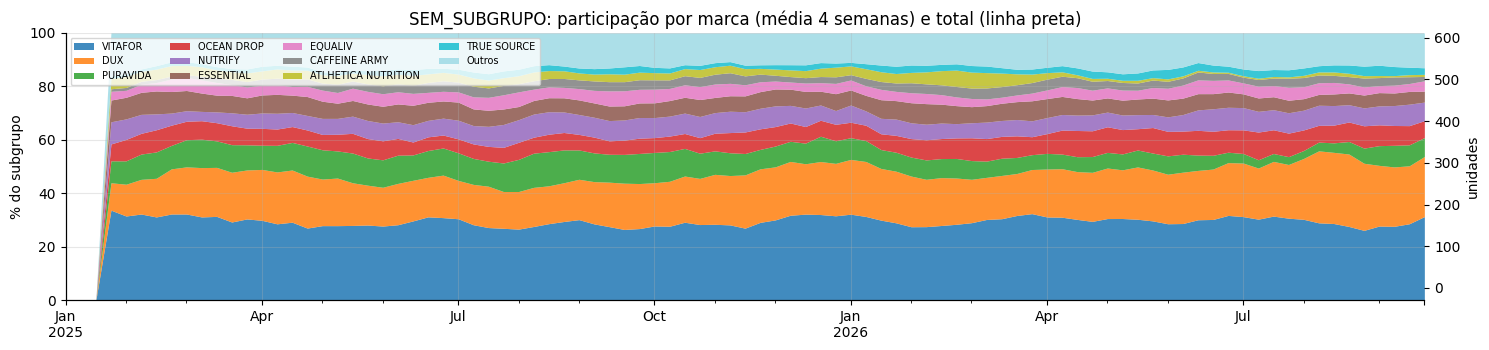

,produtos,HHI,maior participação %,líder
SEM_SUBGRUPO,463,55.890652,3.218636,Creatina Monohidratada


In [6]:
U_an = U.loc[INICIO_ANALISE:]
tam = U_an.T.groupby(GRP).sum().T.sum().sort_values(ascending=False)
top_grp = [g for g in tam.index if (GRP == g).sum() >= 3][:3]
fig, axes = plt.subplots(len(top_grp), 1, figsize=(15, 3.6 * len(top_grp)), squeeze=False)
for ax, g in zip(axes[:, 0], top_grp):
    m = U_an.loc[:, GRP == g].T.groupby(info.loc[GRP == g, 'marca'].astype(str)).sum().T.rolling(4).mean()
    if m.shape[1] > 10:   # 10 maiores marcas + Outros
        top = m.sum().sort_values(ascending=False).index[:10]
        m = m[top].assign(Outros=m.drop(columns=top).sum(axis=1))
    share = m.div(m.sum(axis=1), axis=0) * 100
    share.plot.area(ax=ax, alpha=.85, lw=0, cmap='tab20')
    ax2 = ax.twinx(); ax2.plot(m.index, m.sum(axis=1), color='black', lw=1.5, label='total do subgrupo')
    ax2.set_ylabel(METRICA); ax2.grid(False)
    ax.set_ylim(0, 100); ax.set_ylabel('% do subgrupo'); ax.set_title(f'{g}: participação por marca (média 4 semanas) e total (linha preta)')
    ax.legend(fontsize=7, loc='upper left', ncol=4)
plt.tight_layout(); plt.show()

# concentração (HHI) por subgrupo: 10.000 = um único produto; perto de 0 = muito pulverizado
hhi = {}
for g in tam.index:
    s = U_an.loc[:, GRP == g].sum(); sh = s / s.sum() * 100
    hhi[g] = {'produtos': len(s), 'HHI': (sh ** 2).sum(), 'maior participação %': sh.max(), 'líder': nome(sh.idxmax())}
display(pd.DataFrame(hhi).T.sort_values('HHI', ascending=False).round(1))

## 4. Episódios de pico — a taxa de canibalização
Para cada produto, achamos as semanas em que ele vendeu **≥ `LIMIAR_PICO` × sua linha de base** (mediana das semanas anteriores),
fora de Black Friday e fim de ano (quando tudo sobe junto). Nessas semanas medimos:

- **Δ produto** = quanto ele vendeu acima da base;
- **Δ resto do subgrupo** = quanto os outros produtos do subgrupo venderam acima/abaixo da base deles.

**Taxa de canibalização** = −Δ resto ÷ Δ produto. Exemplo: 0,6 = de cada 10 unidades extras do produto, ~6 deixaram de ser vendidas
por outros do mesmo subgrupo (só 4 foram vendas novas). Perto de 0 = vendas incrementais. Negativa = o subgrupo todo subiu junto.

In [7]:
eventos = pd.Series(0, index=U.index)
for a in range(U.index.min().year, U.index.max().year + 1):
    bf = pm.black_friday(a)
    eventos[(U.index >= bf - pd.Timedelta(days=10)) & (U.index <= bf + pd.Timedelta(days=3))] = 1
    eventos[(U.index >= pd.Timestamp(f'{a}-12-16')) & (U.index <= pd.Timestamp(f'{a + 1}-01-07'))] = 1
linha_base = lambda X: X.shift(1).rolling(SEMANAS_BASE, min_periods=SEMANAS_BASE - 2).median()
BASE = linha_base(U)
DELTA = U - BASE
desc = 1 - F / FC.replace(0, np.nan)          # desconto da semana
desc_base = linha_base(desc)

prod_linhas, par_linhas = [], []
_vol = U.loc[INICIO_ANALISE:].sum()
TOP_GRUPO = set(_vol.groupby(GRP).apply(lambda s: list(s.sort_values(ascending=False).index[:MAX_PARES_POR_GRUPO])).sum())
for g in GRP.unique():
    membros = GRP.index[GRP == g]
    if len(membros) < 2:
        continue
    for a in membros:
        pico = (U[a] >= LIMIAR_PICO * BASE[a]) & (DELTA[a] >= MIN_DELTA_PICO) & (BASE[a] > 0) & (eventos == 0)
        pico &= U.index >= pd.Timestamp(INICIO_ANALISE)
        sem = U.index[pico]
        if len(sem) == 0:
            continue
        outros = [b for b in membros if b != a]
        resto = U[outros].sum(axis=1)
        d_resto = (resto - linha_base(resto)).loc[sem]
        d_a = DELTA.loc[sem, a]
        taxa = -d_resto.sum() / d_a.sum()
        prod_linhas.append({'id_produto': a, 'produto': nome(a), 'marca': info.loc[a, 'marca'], NIVEL_COMPARACAO: g,
                            'episodios': len(sem), 'ganho_nos_picos': d_a.sum(), 'variacao_resto_subgrupo': d_resto.sum(),
                            'taxa_canibalizacao': taxa, 'vendas_incrementais_%': (1 - taxa) * 100,
                            'desconto_no_pico_pp': ((desc.loc[sem, a] - desc_base.loc[sem, a]).mean() * 100),
                            'semanas': ', '.join(s.strftime('%d/%m/%y') for s in sem[-6:])})
        for b in [x for x in outros if x in TOP_GRUPO]:
            par_linhas.append({'a': a, 'b': b, 'episodios_a': len(sem), 'taxa_par': -DELTA.loc[sem, b].sum() / d_a.sum()})

canib_prod = pd.DataFrame(prod_linhas, columns=['id_produto', 'produto', 'marca', NIVEL_COMPARACAO, 'episodios', 'ganho_nos_picos',
                                               'variacao_resto_subgrupo', 'taxa_canibalizacao', 'vendas_incrementais_%',
                                               'desconto_no_pico_pp', 'semanas'])
if canib_prod.empty:
    print('Nenhum pico encontrado com os limiares atuais — reduza LIMIAR_PICO ou MIN_DELTA_PICO.')
confiavel = canib_prod['episodios'] >= MIN_EPISODIOS
def leitura(t):
    if t >= 0.5: return 'forte — a maior parte do ganho veio de produtos do mesmo subgrupo'
    if t >= 0.2: return 'moderada — parte do ganho veio de produtos do mesmo subgrupo'
    if t > -0.2: return 'baixa — o ganho foi, na maior parte, venda nova'
    return 'subgrupo cresceu junto (efeito de atração/tráfego)'
canib_prod['leitura'] = np.where(confiavel, canib_prod['taxa_canibalizacao'].map(leitura), f'poucos picos (< {MIN_EPISODIOS}) — inconclusivo')
print('Produtos com picos — taxa de canibalização (ordenado pela taxa, só os com episódios suficientes no topo):')
display(canib_prod.sort_values(['episodios', 'taxa_canibalizacao'], ascending=[False, False])
        .assign(conf=confiavel).sort_values(['conf', 'taxa_canibalizacao'], ascending=[False, False]).drop(columns='conf')
        .head(15).round(2))

canib_grp = (canib_prod[confiavel].groupby(NIVEL_COMPARACAO)
             .apply(lambda x: pd.Series({'produtos_com_picos': len(x), 'taxa_media_ponderada': -x['variacao_resto_subgrupo'].sum() / x['ganho_nos_picos'].sum()}))
             .sort_values('taxa_media_ponderada', ascending=False))
print(f'\nTaxa por {NIVEL_COMPARACAO} (ponderada pelo ganho):'); display(canib_grp.round(2))

Produtos com picos — taxa de canibalização (ordenado pela taxa, só os com episódios suficientes no topo):


,id_produto,produto,marca,subgrupo,episodios,ganho_nos_picos,variacao_resto_subgrupo,taxa_canibalizacao,vendas_incrementais_%,desconto_no_pico_pp,semanas,leitura
116,943,Whey Protein Isolado,DUX,SEM_SUBGRUPO,3,15.5,-103.0,6.65,-564.52,0.0,"25/08/25, 30/03/26, 15/06/26",forte — a maior parte do ganho veio de produto...
102,900,Barrinha de Proteína,DUX,SEM_SUBGRUPO,7,53.5,-273.0,5.10,-410.28,-0.0,"07/04/25, 21/04/25, 17/11/25, 15/12/25, 27/04/...",forte — a maior parte do ganho veio de produto...
103,901,Barrinha de Proteína,DUX,SEM_SUBGRUPO,3,31.0,-152.5,4.92,-391.94,NaN,"21/04/25, 17/11/25, 18/05/26",forte — a maior parte do ganho veio de produto...
48,397,Vitamina D - Vita D3,VITAFOR,SEM_SUBGRUPO,10,54.0,-209.0,3.87,-287.04,0.0,"20/10/25, 03/11/25, 27/04/26, 04/05/26, 15/06/...",forte — a maior parte do ganho veio de produto...
38,360,Probiótico - Simfort Plus,VITAFOR,SEM_SUBGRUPO,3,16.5,-61.5,3.73,-272.73,-0.0,"05/05/25, 20/04/26, 07/09/26",forte — a maior parte do ganho veio de produto...
90,692,Magnésio Plus 900mg,OCEAN DROP,SEM_SUBGRUPO,4,25.0,-24.0,0.96,4.00,-0.0,"15/09/25, 17/11/25, 06/04/26, 25/05/26",forte — a maior parte do ganho veio de produto...
20,141,Creatina Monohidratada,ATLHETICA NUTRITION,SEM_SUBGRUPO,6,48.5,77.5,-1.60,259.79,0.0,"27/10/25, 09/02/26, 16/02/26, 23/02/26, 02/03/...",subgrupo cresceu junto (efeito de atração/tráf...
95,72,Ômega 3 EPA DHA,VITAFOR,SEM_SUBGRUPO,3,17.5,35.5,-2.03,302.86,-0.0,"09/03/26, 06/04/26, 13/04/26",subgrupo cresceu junto (efeito de atração/tráf...
60,433,Cúrcuma Plus,VITAFOR,SEM_SUBGRUPO,8,55.0,134.0,-2.44,343.64,-0.0,"19/05/25, 02/06/25, 23/06/25, 10/11/25, 11/05/...",subgrupo cresceu junto (efeito de atração/tráf...
10,1214,Ômega 3 - EPA DHA - 1000mg,EQUALIV,SEM_SUBGRUPO,3,18.0,49.0,-2.72,372.22,-0.0,"09/02/26, 04/05/26, 27/07/26",subgrupo cresceu junto (efeito de atração/tráf...



Taxa por subgrupo (ponderada pelo ganho):


,produtos_com_picos,taxa_media_ponderada
subgrupo,,
SEM_SUBGRUPO,38.0,-5.96


## 5. Correlação das variações semanais
Variação semanal de cada produto **menos a variação da loja inteira** (para não confundir com sazonalidade/crescimento geral).
Correlação negativa entre produtos do mesmo subgrupo = quando um sobe, o outro desce.

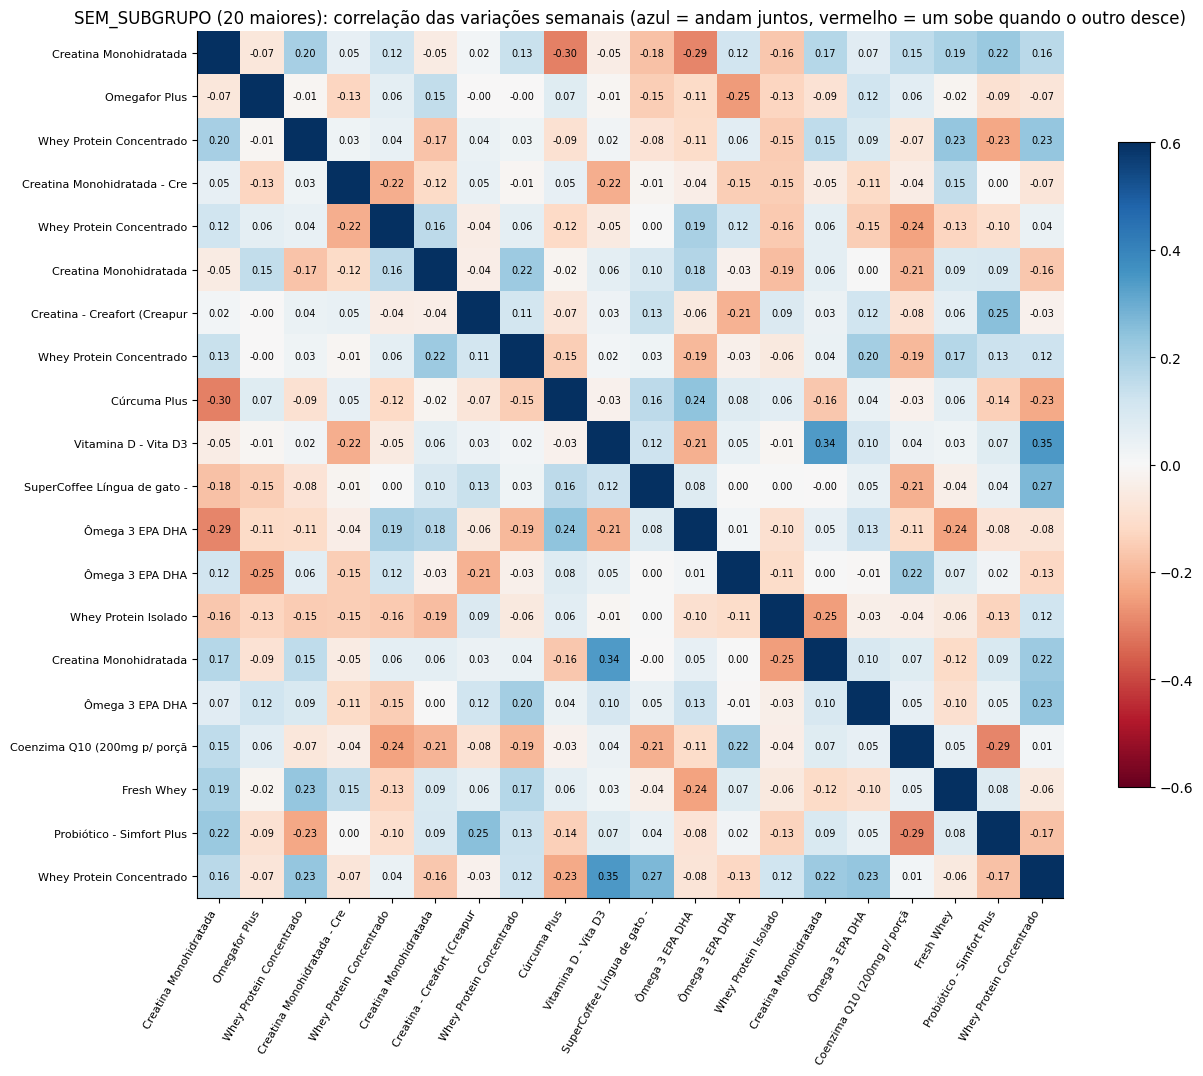

In [8]:
var = np.log1p(U.loc[INICIO_ANALISE:]).diff()
loja = np.log1p(U.loc[INICIO_ANALISE:].sum(axis=1)).diff()
resid = var.sub(loja, axis=0).dropna(how='all')
CORR = resid.corr()

g = top_grp[0]
# só os 20 produtos de maior volume do subgrupo: com centenas, o gráfico fica ilegível e pode estourar a memória
membros = U_an.loc[:, GRP == g].sum().sort_values(ascending=False).index[:20]
cm = CORR.loc[membros, membros]
fig, ax = plt.subplots(figsize=(1 + 0.6 * len(membros), 0.5 * len(membros) + 1))
im = ax.imshow(cm.values, cmap='RdBu', vmin=-.6, vmax=.6)
rot = [nome(i)[:28] for i in membros]
ax.set_xticks(range(len(membros)), rot, rotation=60, ha='right', fontsize=8); ax.set_yticks(range(len(membros)), rot, fontsize=8)
for i in range(len(membros)):
    for j in range(len(membros)):
        if i != j: ax.text(j, i, f'{cm.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.grid(False); ax.set_title(f'{g} (20 maiores): correlação das variações semanais (azul = andam juntos, vermelho = um sobe quando o outro desce)')
plt.colorbar(im, ax=ax, shrink=.7); plt.tight_layout(); plt.show()

## 6. Cesta: compram juntos?
**Lift** = quantas vezes mais os dois aparecem no mesmo pedido do que o acaso esperaria.
Lift < 1 = raramente juntos (compatível com substitutos: o cliente escolhe um *ou* outro). Lift > 1,5 = complementares.

In [9]:
cesta = fonte.df(ld.sql_cesta_pares(cols, DIAS_CESTA, TOP_PRODUTOS_CESTA, DEDUP_ITENS), 'cesta_pares', datas=())
for c in ('produto_a', 'produto_b'):
    cesta[c] = cesta[c].astype(str)
cesta['lift'] = cesta['pedidos_juntos'] * cesta['total_pedidos'] / (cesta['pedidos_a'] * cesta['pedidos_b'])
LIFT = {}
for r in cesta.itertuples():
    LIFT[(r.produto_a, r.produto_b)] = LIFT[(r.produto_b, r.produto_a)] = (r.lift, r.pedidos_juntos)
top_lift = cesta[cesta['pedidos_juntos'] >= 10].sort_values('lift', ascending=False).head(10).copy()
top_lift['A'] = top_lift['produto_a'].map(lambda i: nome(i) if i in info.index else i)
top_lift['B'] = top_lift['produto_b'].map(lambda i: nome(i) if i in info.index else i)
print('Pares mais comprados juntos (complementares):'); display(top_lift[['A', 'B', 'pedidos_juntos', 'lift']].round(2))

Pares mais comprados juntos (complementares):


,A,B,pedidos_juntos,lift
593,Creatina Monohidratada,Whey Tech 100%,23.0,12.37
452,Omegafor Plus,Coenzima Q10 (200mg p/ porção),12.0,11.38
208,Ômega 3 - Omegafor Memory,Cúrcuma Plus,11.0,8.11
83,"Boraprim - Borragem, Prímula e Gergelim",Probiótico - Simfort Plus,10.0,7.65
27,Ômega 3 - EPA DHA - 1000mg,Vitamina D - Vita D3,11.0,7.60
153,Cúrcuma Plus,Coenzima Q10 (200mg p/ porção),21.0,6.26
219,Ômega 3 - EPA DHA - 1000mg,Cúrcuma Plus,11.0,6.14
168,Resveratrol Plus - 165mg,Cúrcuma Plus,12.0,6.11
459,Whey Tech 100%,Ômega 3 EPA DHA,10.0,5.38
127,"Boraprim - Borragem, Prímula e Gergelim",Cúrcuma Plus,10.0,5.09


## 7. Agrupamento por comportamento: KNN e K-means
Cada produto vira um "retrato" de como é comprado — **sem usar o cadastro**:
preço médio por unidade, desconto médio, % das vendas via nutricionista, tendência (13 semanas vs. 13 anteriores),
volatilidade, perfil sazonal (participação de cada trimestre) e o formato da curva de vendas semanais.

- **KNN:** os `K_VIZINHOS` produtos mais parecidos com cada um → candidatos a substitutos.
- **Teste do cadastro:** um classificador KNN tenta adivinhar o subgrupo só pelo comportamento. Acerto alto = o cadastro
  reflete como o cliente compra; acerto baixo = vale revisar o agrupamento usado nas previsões.
- **K-means (BigQuery ML via bigframes):** perfis de produtos e de marcas.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans as KMeansSK
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Ua, Fa, FCa = U.loc[INICIO_ANALISE:], F.loc[INICIO_ANALISE:], FC.loc[INICIO_ANALISE:]
canal = pc.pivot_table(index='id_produto', columns='canal', values='faturamento', aggfunc='sum').reindex(ativos).fillna(0)
feat = pd.DataFrame(index=ativos)
feat['log_preco_unidade'] = np.log(Fa.sum() / Ua.sum().replace(0, np.nan))
feat['desconto_medio'] = 1 - Fa.sum() / FCa.sum().replace(0, np.nan)
feat['pct_nutricionista'] = canal.get('COM_NUTRICIONISTA', 0) / canal.sum(axis=1).replace(0, np.nan)
feat['tendencia'] = np.log1p(Ua.iloc[-13:].sum()) - np.log1p(Ua.iloc[-26:-13].sum())
feat['volatilidade'] = Ua.std() / Ua.mean().replace(0, np.nan)
tri = Ua.groupby(Ua.index.quarter).sum()
for q in tri.index:
    feat[f'tri{q}'] = tri.loc[q] / tri.sum()
# formato da curva (padronizada, suavizada mensalmente) — produtos que sobem e descem juntos ficam próximos
curva = Ua.resample('MS').sum()
curva = (curva - curva.mean()) / curva.std().replace(0, 1)
pca_curva = PCA(n_components=min(4, curva.shape[0] - 1), random_state=SEED).fit_transform(curva.T.fillna(0))
for k in range(pca_curva.shape[1]):
    feat[f'curva_{k + 1}'] = pca_curva[:, k]
feat = feat.fillna(feat.median())
Z = pd.DataFrame(StandardScaler().fit_transform(feat), index=feat.index, columns=feat.columns)

# --- KNN: vizinhos
nn = NearestNeighbors(n_neighbors=min(K_VIZINHOS + 1, len(Z)), metric='euclidean').fit(Z)
dist, idx = nn.kneighbors(Z)
viz = []
for i, a in enumerate(Z.index):
    for d, j in zip(dist[i][1:], idx[i][1:]):
        b = Z.index[j]
        viz.append({'id_produto': a, 'produto': nome(a), 'vizinho_id': b, 'vizinho': nome(b), 'distancia': d,
                    f'mesmo_{NIVEL_COMPARACAO}': GRP[a] == GRP[b], 'mesma_marca': info.loc[a, 'marca'] == info.loc[b, 'marca']})
vizinhos = pd.DataFrame(viz)
print(f"Vizinhos no mesmo {NIVEL_COMPARACAO}: {vizinhos[f'mesmo_{NIVEL_COMPARACAO}'].mean() * 100:.0f}% | "
      f"mesma marca: {vizinhos['mesma_marca'].mean() * 100:.0f}%")
display(vizinhos[vizinhos.id_produto.isin(U_an.sum().sort_values(ascending=False).index[:5])].round(2))

# --- teste do cadastro: o comportamento "adivinha" o subgrupo?
y_cad = GRP.loc[Z.index]
ok = y_cad.map(y_cad.value_counts()) >= 3
n_spl = int(min(5, y_cad[ok].value_counts().min()))
if ok.sum() >= 10 and n_spl >= 2:
    knn_c = KNeighborsClassifier(n_neighbors=3)
    acc = cross_val_score(knn_c, Z[ok], y_cad[ok], cv=StratifiedKFold(n_spl, shuffle=True, random_state=SEED)).mean()
    acaso = (y_cad[ok].value_counts(normalize=True) ** 2).sum()
    print(f'\nKNN acerta o {NIVEL_COMPARACAO} de {acc * 100:.0f}% dos produtos só pelo comportamento (acaso: {acaso * 100:.0f}%).')

Vizinhos no mesmo subgrupo: 100% | mesma marca: 16%


,id_produto,produto,vizinho_id,vizinho,distancia,mesmo_subgrupo,mesma_marca
1515,486,Creatina Monohidratada,860,Fresh Whey,1.96,True,True
1516,486,Creatina Monohidratada,448,Coenzima Q10 (200mg p/ porção),2.21,True,False
1517,486,Creatina Monohidratada,908,Vitamina D3 + K2,2.29,True,False
1518,486,Creatina Monohidratada,421,Glutamina - Glutamax,2.67,True,False
1519,486,Creatina Monohidratada,685,Creatina Monohidratada,2.79,True,False
1785,68,Omegafor Plus,402,Probiótico - Simfort Plus,1.15,True,True
1786,68,Omegafor Plus,939,Whey Protein Concentrado,1.49,True,False
1787,68,Omegafor Plus,936,Whey Protein Concentrado,1.58,True,False
1788,68,Omegafor Plus,434,Creatina - Creafort (Creapure),1.61,True,True
1789,68,Omegafor Plus,72,Ômega 3 EPA DHA,1.76,True,True



KNN acerta o subgrupo de 100% dos produtos só pelo comportamento (acaso: 100%).


silhouette por k: {3: np.float64(0.112), 4: np.float64(0.125), 5: np.float64(0.107), 6: np.float64(0.126), 7: np.float64(0.134), 8: np.float64(0.122)} → k = 7


Perfis de produtos (médias por cluster):


,produtos,preco_unidade,desconto_medio,pct_nutricionista,tendencia,volatilidade,exemplos
cluster,,,,,,,
0,53,82.08,0.00,1.00,0.18,1.51,"Pasta de Amendoim, Colágeno - Collagen Essenti..."
1,34,36.38,0.00,0.97,0.12,1.97,"Gold Whey Concentrado Refil, Suplemento Alimen..."
2,21,89.42,0.00,0.99,1.01,1.75,"Própolis Alcoólico, Coenzima Q10, Whey Protein..."
3,123,119.31,0.00,1.00,0.02,1.27,"Ômega Core, Suplemento - Hyaluronic Hair, Próp..."
4,7,26.22,0.06,0.97,0.57,2.07,"Ômega 3, Salgadinho, NAC PRO"
5,101,109.21,0.00,1.00,-0.95,1.62,"Ômega Golden, Tasty Whey 3W Gourmet, Barrinha ..."
6,124,98.56,0.00,1.00,-0.17,1.37,"Whey 3W, Colágeno - Collagen Pro - Body Suport..."


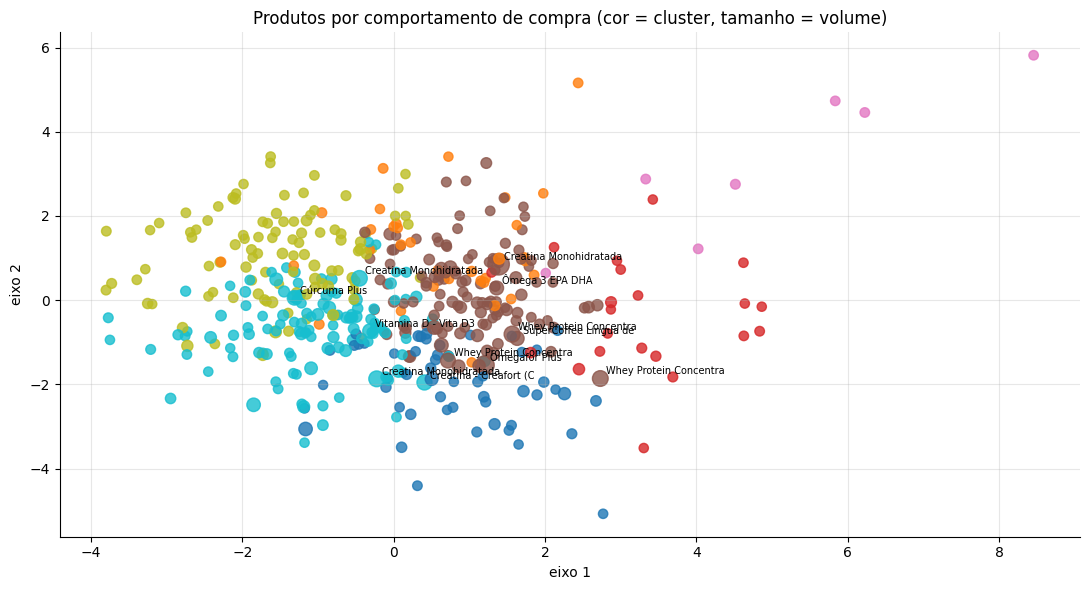

Clusters de marcas:


,log_preco_unidade,desconto_medio,pct_nutricionista,tendencia,mix_SEM_GRUPO,cluster
marca,,,,,,
WS NATURAIS,3.31,-0.00,1.00,-1.79,1.0,0
FLORMEL,1.98,-0.00,0.98,-0.42,1.0,1
LIQUIDZ,2.81,-0.00,0.99,-0.35,1.0,1
ONLY4,3.29,0.00,0.96,1.10,1.0,1
ZEROMILK,2.96,-0.00,0.98,0.41,1.0,1
LAUTON,3.79,-0.00,0.98,0.17,1.0,1
DUX,4.86,0.00,0.99,0.09,1.0,2
CAFFEINE ARMY,5.04,0.01,0.99,-0.16,1.0,2
CENTRAL NUTRITION,5.13,0.01,1.00,-0.03,1.0,2


In [11]:
# --- K-means: número de grupos pelo silhouette (local) e ajuste final no BigQuery ML (bigframes) quando disponível
if N_CLUSTERS is None:
    sil = {k: silhouette_score(Z, KMeansSK(k, n_init=10, random_state=SEED).fit_predict(Z)) for k in range(3, min(9, len(Z) - 1))}
    N_CLUSTERS = max(sil, key=sil.get)
    print('silhouette por k:', {k: round(v, 3) for k, v in sil.items()}, '→ k =', N_CLUSTERS)

def kmeans(X, k):
    if MODO == 'bigquery':
        from bigframes.ml.cluster import KMeans as KMeansBQ
        bx = fonte.bpd.read_pandas(X.reset_index(drop=True))
        mdl = KMeansBQ(n_clusters=k, distance_type='euclidean', max_iter=50).fit(bx)
        out = mdl.predict(bx).to_pandas().sort_index()   # mesma ordem das linhas de X
        return out['CENTROID_ID'].astype(int).values - 1
    return KMeansSK(k, n_init=10, random_state=SEED).fit_predict(X)

info['cluster'] = kmeans(Z, N_CLUSTERS)
perfil = feat.groupby(info['cluster']).mean()
perfil['produtos'] = info['cluster'].value_counts()
perfil['exemplos'] = info.groupby('cluster')['produto_nome'].apply(lambda s: ', '.join(s.head(3)))
perfil['preco_unidade'] = np.exp(perfil['log_preco_unidade'])
print('Perfis de produtos (médias por cluster):')
display(perfil[['produtos', 'preco_unidade', 'desconto_medio', 'pct_nutricionista', 'tendencia', 'volatilidade', 'exemplos']].round(2))

p2 = PCA(2, random_state=SEED).fit_transform(Z)
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(p2[:, 0], p2[:, 1], c=info['cluster'], cmap='tab10', s=40 + 200 * (Ua.sum() / Ua.sum().max()).values, alpha=.8)
for i in np.argsort(-Ua.sum().values)[:12]:
    ax.annotate(nome(Z.index[i])[:22], p2[i], fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set_title('Produtos por comportamento de compra (cor = cluster, tamanho = volume)'); ax.set_xlabel('eixo 1'); ax.set_ylabel('eixo 2')
plt.tight_layout(); plt.show()

# marcas: retrato agregado (preço, canal, desconto, mix de grupos)
mf = feat.join(info[['marca', 'grupo']]).assign(peso=Ua.sum())
mix = Ua.sum().groupby([info['marca'], info['grupo']]).sum().unstack(fill_value=0)
mix = mix.div(mix.sum(axis=1), axis=0).add_prefix('mix_')
marca_feat = mf.groupby('marca').apply(lambda x: pd.Series({c: np.average(x[c], weights=x['peso'] + 1e-9)
                                       for c in ['log_preco_unidade', 'desconto_medio', 'pct_nutricionista', 'tendencia']})).join(mix)
if len(marca_feat) >= 4:
    kz = StandardScaler().fit_transform(marca_feat)
    marca_feat['cluster'] = kmeans(pd.DataFrame(kz, columns=marca_feat.columns), min(N_CLUSTERS, len(marca_feat) - 1))
    print('Clusters de marcas:'); display(marca_feat.sort_values('cluster').round(2))

## 8. Quadro final: quem concorre com quem
Pares do mesmo subgrupo **ou** vizinhos no KNN, com os quatro sinais lado a lado:

| Classificação | Regra (todas as evidências disponíveis) |
|---|---|
| **Concorrem entre si** | mesmo subgrupo: taxa no par ≥ 0,15 **ou** correlação ≤ −0,15; subgrupos diferentes: vizinhos no KNN e correlação ≤ −0,25. Em ambos, lift < 1,2 |
| **Complementares** | lift ≥ 1,5 e correlação ≥ 0 |
| **Sem relação clara** | demais casos |

In [12]:
taxas = pd.DataFrame(par_linhas, columns=['a', 'b', 'episodios_a', 'taxa_par'])
pares = set()
for g in GRP.unique():
    m = [x for x in GRP.index[GRP == g] if x in TOP_GRUPO]
    pares |= {tuple(sorted((a, b))) for i, a in enumerate(m) for b in m[i + 1:]}
PARES_KNN = {tuple(sorted((r.id_produto, r.vizinho_id))) for r in vizinhos.itertuples()}
pares |= PARES_KNN

# taxa por par (média ponderada pelos episódios, nos dois sentidos) — pré-calculada uma vez
_t = taxas[taxas.episodios_a >= MIN_EPISODIOS].copy()
_t['par'] = [tuple(sorted(x)) for x in zip(_t.a, _t.b)]
_t['tx_w'] = _t.taxa_par * _t.episodios_a
_agg = _t.groupby('par').agg(tx_w=('tx_w', 'sum'), ep=('episodios_a', 'sum'))
TAXA_PAR = {k: (r.tx_w / r.ep, int(r.ep)) for k, r in _agg.iterrows()}
def taxa_simetrica(a, b):
    return TAXA_PAR.get(tuple(sorted((a, b))), (np.nan, 0))

linhas = []
for a, b in pares:
    tx, ep = taxa_simetrica(a, b)
    lift, juntos = LIFT.get((a, b), (np.nan, 0))
    linhas.append({'produto_a': nome(a), 'marca_a': info.loc[a, 'marca'], 'produto_b': nome(b), 'marca_b': info.loc[b, 'marca'],
                   'id_a': a, 'id_b': b, f'{NIVEL_COMPARACAO}_a': GRP[a], f'{NIVEL_COMPARACAO}_b': GRP[b],
                   f'mesmo_{NIVEL_COMPARACAO}': GRP[a] == GRP[b],
                   'vizinhos_knn': tuple(sorted((a, b))) in PARES_KNN,
                   'correlacao': CORR.loc[a, b], 'taxa_canibalizacao_par': tx, 'episodios': ep, 'lift_cesta': lift, 'pedidos_juntos': juntos})
quadro = pd.DataFrame(linhas)

def classificar(r):
    lift_ok = np.isnan(r.lift_cesta) or r.lift_cesta < 1.2
    mesmo = r[f'mesmo_{NIVEL_COMPARACAO}']
    sinal = (r.taxa_canibalizacao_par >= 0.15) or (r.correlacao <= -0.15) if mesmo else (r.vizinhos_knn and r.correlacao <= -0.25)
    if sinal and lift_ok:
        return 'Concorrem entre si'
    if (r.lift_cesta >= 1.5) and (r.correlacao >= 0):
        return 'Complementares'
    return 'Sem relação clara'
def explicar(r):
    p = []
    if not np.isnan(r.taxa_canibalizacao_par):
        p.append(f'nos picos de um, o outro perdeu ~{max(r.taxa_canibalizacao_par, 0) * 100:.0f}% do ganho' if r.taxa_canibalizacao_par > 0
                 else 'nos picos de um, o outro não caiu')
    p.append(f'variações {"opostas" if r.correlacao < -0.1 else "parecidas" if r.correlacao > 0.1 else "independentes"} (corr. {r.correlacao:+.2f})')
    if not np.isnan(r.lift_cesta):
        p.append(f'saem juntos {r.lift_cesta:.1f}× o esperado')
    return '; '.join(p)
quadro['classificacao'] = quadro.apply(classificar, axis=1)
quadro['explicacao'] = quadro.apply(explicar, axis=1)
quadro['forca'] = quadro['taxa_canibalizacao_par'].fillna(0).clip(lower=0) + (-quadro['correlacao']).clip(lower=0)
quadro = quadro.sort_values(['classificacao', 'forca'], ascending=[True, False])
display(quadro['classificacao'].value_counts().to_frame('pares'))
print('Pares que mais concorrem entre si:')
display(quadro[quadro.classificacao == 'Concorrem entre si'][['produto_a', 'produto_b', f'mesmo_{NIVEL_COMPARACAO}', 'vizinhos_knn',
        'taxa_canibalizacao_par', 'correlacao', 'lift_cesta', 'explicacao']].head(15).round(2))

,pares
classificacao,
Sem relação clara,2096
Concorrem entre si,193
Complementares,110


Pares que mais concorrem entre si:


,produto_a,produto_b,mesmo_subgrupo,vizinhos_knn,taxa_canibalizacao_par,correlacao,lift_cesta,explicacao
1964,Whey Tech 100%,Ômega 3 EPA DHA,True,False,0.69,-0.21,NaN,"nos picos de um, o outro perdeu ~69% do ganho;..."
969,Whey Tech 100%,Whey Protein Isolado,True,False,0.74,0.17,NaN,"nos picos de um, o outro perdeu ~74% do ganho;..."
1199,Whey Tech 100%,Whey Protein Concentrado,True,False,0.58,-0.06,NaN,"nos picos de um, o outro perdeu ~58% do ganho;..."
202,Whey Tech 100%,Whey Protein Isolado,True,False,0.42,-0.17,NaN,"nos picos de um, o outro perdeu ~42% do ganho;..."
1474,Colágeno - Colagentek Protein - Bodybalance,Omegafor Plus,True,False,0.40,-0.14,NaN,"nos picos de um, o outro perdeu ~40% do ganho;..."
491,Coenzima Q10 + Ômega 3 + Vitamina E,Whey Protein Concentrado,True,False,0.18,-0.29,NaN,"nos picos de um, o outro perdeu ~18% do ganho;..."
1211,Probiótico - Simfort Plus,Ômega 3 - 1360mg,True,False,0.09,-0.36,0.61,"nos picos de um, o outro perdeu ~9% do ganho; ..."
1194,Creatina Monohidratada,Whey Protein Isolado,True,False,0.17,-0.25,0.28,"nos picos de um, o outro perdeu ~17% do ganho;..."
295,Creatina Monohidratada,Ômega 3 EPA DHA,True,False,0.11,-0.29,0.91,"nos picos de um, o outro perdeu ~11% do ganho;..."
1864,Probiótico - Simfort Plus,Whey Protein Isolado,True,False,0.39,-0.02,NaN,"nos picos de um, o outro perdeu ~39% do ganho;..."


## 9. O que isso muda na previsão
- Subgrupos com **canibalização forte**: prever o **subgrupo** (série mais estável) e distribuir entre marcas/produtos pela
  participação recente (**top-down**). O notebook de previsão já testa essa opção (`Top-down (pai × part.)`) e só a escolhe se
  ela errar menos.
- Promoção de um produto que **concorre** com outros: a previsão do subgrupo não deve subir na mesma proporção do pico do produto.
- Pares **complementares**: oportunidade de kit/combo; a previsão de um pode usar o outro como sinal.

In [13]:
rec = canib_grp.copy()
rec['recomendacao'] = np.select(
    [rec['taxa_media_ponderada'] >= 0.4, rec['taxa_media_ponderada'] >= 0.2],
    [f'forte: prever o {NIVEL_COMPARACAO} e distribuir por participação (top-down)',
     'moderada: comparar previsão direta × top-down no notebook de previsão'],
    'baixa: prever produto/marca diretamente é aceitável')
display(rec.round(2))

saidas = {'liah_canibalizacao_pares': quadro, 'liah_canibalizacao_produtos': canib_prod,
          f'liah_canibalizacao_{NIVEL_COMPARACAO}': rec.reset_index(), 'liah_produtos_vizinhos': vizinhos,
          'liah_clusters_produtos': info.join(feat).reset_index(),
          'liah_clusters_marcas': marca_feat.reset_index() if 'cluster' in marca_feat else pd.DataFrame()}
# Lê o que já está em saida/ e atualiza: mantém rodadas anteriores, substitui a mesma data_base.
MANTER_RODADAS_ANTERIORES = True
data_base = ultima_sem + pd.Timedelta(days=6)
print('Atualizando saida/:')
for k, d in saidas.items():
    if d.empty:
        continue
    completo = ld.atualizar_saida(d.assign(data_base=data_base), k, substituir_tudo=not MANTER_RODADAS_ANTERIORES)
    if DATASET_SAIDA:
        fonte.salvar_tabela(completo, f'{DATASET_SAIDA}.{k}')

,produtos_com_picos,taxa_media_ponderada,recomendacao
subgrupo,,,
SEM_SUBGRUPO,38.0,-5.96,baixa: prever produto/marca diretamente é acei...


Atualizando saida/:
  liah_canibalizacao_pares.csv: 2399 linhas — 0 rodada(s) anterior(es) mantida(s); 2399 linha(s) da mesma data substituída(s)
  liah_canibalizacao_produtos.csv: 119 linhas — 0 rodada(s) anterior(es) mantida(s); 119 linha(s) da mesma data substituída(s)
  liah_canibalizacao_subgrupo.csv: 1 linhas — 0 rodada(s) anterior(es) mantida(s); 1 linha(s) da mesma data substituída(s)
  liah_produtos_vizinhos.csv: 2315 linhas — 0 rodada(s) anterior(es) mantida(s); 2315 linha(s) da mesma data substituída(s)
  liah_clusters_produtos.csv: 463 linhas — 0 rodada(s) anterior(es) mantida(s); 463 linha(s) da mesma data substituída(s)
  liah_clusters_marcas.csv: 37 linhas — 0 rodada(s) anterior(es) mantida(s); 37 linha(s) da mesma data substituída(s)


In [14]:
fonte.resumo_custo()   # consultas feitas no BigQuery × reaproveitadas do cache

Consultas ao BigQuery: 0 [] | reaproveitadas do cache (sem custo): 4 ['schema', 'diaria', 'cubo_produto', 'cesta_pares']
